# Task 6 

Everything so far checked each pixel on its own: is it above the threshold or not.
Region growing is different. You drop a seed somewhere and spread outwards, and a
neighbouring pixel only joins if its intensity is close enough to the seed's.

So the result is always one connected blob, instead of white pixels scattered all over
the image like a threshold gives you.

Writing it myself since the lab says no prebuilt segmentation library. Using a stack
instead of recursion so it doesn't blow up on a big image, and checking 4 neighbours
(up, down, left, right).

Parameters:
* Seed A at the centre of the image, Seed B at (w/3, h/3)
* Thresholds 10, 25 and 40

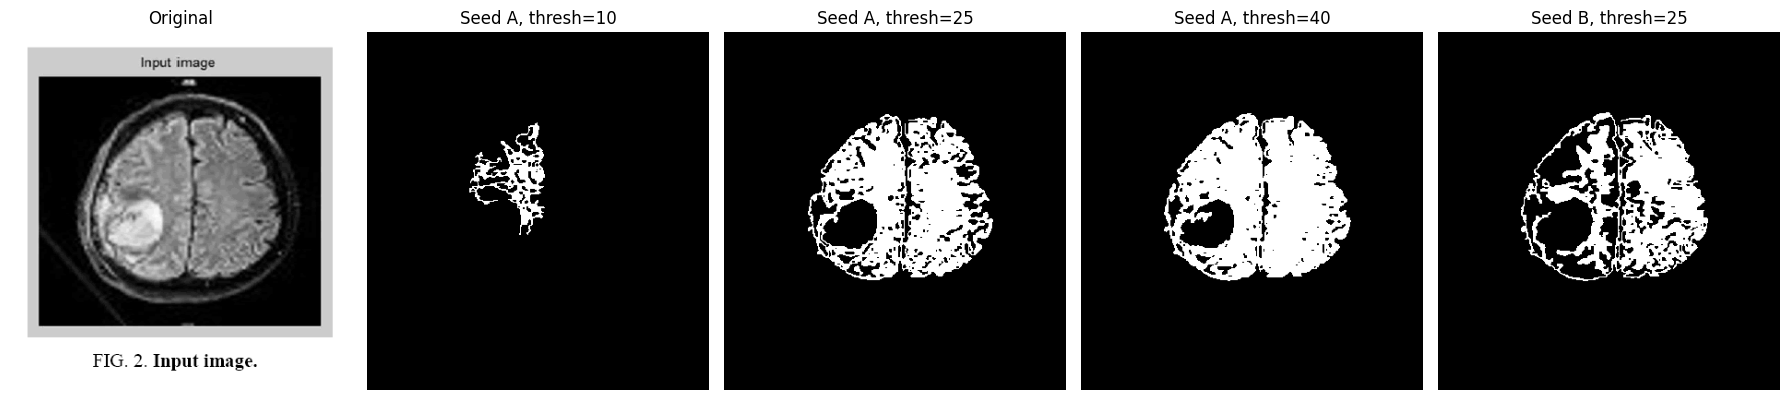

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region_grow(img, seed, threshold):
    h, w = img.shape
    mask = np.zeros((h, w), np.uint8)
    seed_value = int(img[seed[1], seed[0]])

    stack = [seed]
    mask[seed[1], seed[0]] = 255

    while stack:
        x, y = stack.pop()

        # check the 4 neighbours
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy

            if 0 <= nx < w and 0 <= ny < h and mask[ny, nx] == 0:
                # join the region if intensity is close enough
                if abs(int(img[ny, nx]) - seed_value) <= threshold:
                    mask[ny, nx] = 255
                    stack.append((nx, ny))

    return mask


img = cv2.imread("brain.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: brain.jpg not found")
else:
    h, w = img.shape

    seed_a = (w // 2, h // 2)        # middle of the brain
    seed_b = (w // 3, h // 3)        # a different area

    # Same seed, three different thresholds
    r1 = region_grow(img, seed_a, 10)
    r2 = region_grow(img, seed_a, 25)
    r3 = region_grow(img, seed_a, 40)

    # Different seed, same threshold
    r4 = region_grow(img, seed_b, 25)

    titles = ["Original",
              "Seed A, thresh=10",
              "Seed A, thresh=25",
              "Seed A, thresh=40",
              "Seed B, thresh=25"]
    images = [img, r1, r2, r3, r4]

    plt.figure(figsize=(18, 4))
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i], cmap="gray")
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### Results

**Effect of the threshold (all using Seed A)**

* **10**: the region stays really small, it stops at the tiniest intensity change
* **25**: best one, fills up one proper structure
* **40**: leaks across the boundaries and floods into the surrounding tissue

So there's a clear trade-off. Too low and you only get a fragment; too high and the
region escapes into areas that shouldn't be included.

**Why can changing the seed point significantly change the final region?**

Two reasons.

First, the seed's intensity is the reference value that every other pixel gets compared
against. If the seed lands on brighter tissue, the region grows through bright tissue. A
seed a bit further away on darker tissue grows through something completely different.

Second, the seed decides what's even reachable. The region can only spread through
connected pixels that pass the intensity test, so it can't jump across a dark boundary.
Two areas with the exact same intensity will never end up in the same region if there's
an edge between them. So the seed controls both what intensity you're chasing and which
parts of the image you can actually get to.

You can see this in the last panel. Seed B with the same threshold of 25 gives a
totally different region than Seed A did.